In [1]:
import pandas as pd
import numpy as np
import re
import json
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from scipy.stats import entropy
import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
np.set_printoptions(suppress=True)

data= pd.read_csv("anti_total.csv".strip('\u202a'), index_col=False)
# data= pd.read_csv(r"‪D:\ML Data\Spesis\anti_total.csv".strip('\u202a'), index_col=False)

In [3]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [4]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [5]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [6]:
final_cols = col_sum[col_sum >= 400].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [7]:
data_filter[final_cols].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Peramivir                      1119.0
Baloxavir marboxil             1085.0
Metronidazole                  1020.0
Cefadroxil                      918.0
Oseltamivir                     835.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Cephalexin                      517.0
Ampicillin                      423.0
dtype: float64

In [8]:
len(data_filter), len(data_filter['ACCOUNTNO'])

(27968, 27968)

In [9]:
data_filter['Clindamycin'].sum(), data_filter['Gentamicin'].sum()

(624.0, 623.0)

In [10]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9'
]

temp_site = data_filter[all_site_cols].copy()

# robust cleaning（避免奇怪值）
temp_site = (
    temp_site.astype(str)
    .apply(lambda x: x.str.strip())
    .replace(['', 'nan', 'None', 'nan.0'], '0')
    .astype(float)
)

# 建 flag
data_filter = data_filter.copy()
data_filter['Miss_INFECTSITE_flag'] = (temp_site == 0).all(axis=1).astype(int)

In [11]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
data_filter = data_filter.copy()
data_filter['ROOMNO'] = data_filter['ROOMNO'].map(roomno_mapping)          

data_filter['SEX'] = data_filter['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    data_filter[col] = data_filter[col].map({'Y': 1, 'N': 0})

In [12]:
feature_cols = list(set(data_filter.columns) - set(abx_cols))
X = data_filter[feature_cols]
y = data_filter[final_cols]

In [13]:
X.shape, y.shape

((27968, 70), (27968, 20))

In [14]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0', 'Bacteria level'])
y = y.drop(columns=['Peramivir', 'Baloxavir marboxil', 'Oseltamivir'])#, 'Cephalexin', 'Cefadroxil'])
                    #'Amoxicillin', 'Doxycycline', 'Acyclovir', 'Valaciclovir', 'Tenofovir alafenamide', 'Ceftazidime'])# 去掉抗病毒的藥(前3) 

In [15]:
# 找出至少有一種藥物的樣本 (Row sum > 0)
has_label_mask = (y.sum(axis=1) > 0)

# 同步過濾 X 和 y
X = X[has_label_mask]
y = y[has_label_mask]

print(f"原本樣本數: {len(has_label_mask)}")
print(f"過濾後樣本數: {len(y)}")
print(f"已刪除 {len(has_label_mask) - len(y)} 筆因刪除藥物欄位而變成『無給藥』的樣本")

原本樣本數: 27968
過濾後樣本數: 23809
已刪除 4159 筆因刪除藥物欄位而變成『無給藥』的樣本


In [16]:
X.columns

Index(['HST', 'VITALSIGNSDBP', 'CHECKITEM29SCORE', 'AGE', 'Creatinine', 'PT',
       'FEVER', 'CHECKITEM27', 'VITALSIGNSSPO2', 'Neutrophil Seg.',
       'CHECKITEM28A', 'VITALSIGNSRR', 'Nitrite level', 'VITALSIGNSGCS', 'PH',
       'INFECTIONSITE4', 'O2 SAT', 'INJURELEVEL', 'AUTOIMMUNE',
       'INFECTIONSITE5', 'INFECTIONSITE3', 'CHECKITEM31SCORE',
       'CHECKITEM30SCORE', 'INFECTIONSITE2', 'MAP', 'CHECKITEM27SCORE',
       'KIDNEY', 'CRP', 'Miss_INFECTSITE_flag', 'LIVER', 'Lymphocyte',
       'CHECKITEM32SCORE', 'RBC', 'RESPIRATORY', 'CHECKITEM28SCORE',
       'Microscopic RBC level', 'T.Bilirubin', 'BE(ecf)',
       'OTHERINFECTIONSITE_flag', 'CARDIOVASCULAR', 'INFECTIONSITE9', 'HCO3',
       'DM', 'PLT', 'CANCER', 'WBC', 'StayTime_hours', 'PCO2', 'SEX',
       'Absolute Neutrophil count', 'K', 'GPT', 'Hb', 'Ht', 'INFECTIONSITE1',
       'INR', 'APTT', 'CNS', 'Leukocyte level', 'Microscopic WBC level',
       'VITALSIGNSPR', 'Na', 'VITALSIGNSBT'],
      dtype='object')

In [17]:
y[y.columns].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Metronidazole                  1020.0
Cefadroxil                      918.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Cephalexin                      517.0
Ampicillin                      423.0
dtype: float64

In [18]:
# ####################### Missing 70~80% #######################

# # 檢驗

# X['Leukocyte level_flag'] = (
#      X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

# X['Nitrite level_flag'] = (
#      X['Nitrite level'].fillna('').str.strip().ne('').astype(int))

# X['Bacteria level_flag'] = (
#      X['Bacteria level'].fillna('').str.strip().ne('').astype(int))

# X['Microscopic RBC level_flag'] = (
#      X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

# X['Microscopic WBC level_flag'] = (
#      X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

# X['PH_flag'] = (
#      X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# # 計分

# X['CHECKITEM29SCORE_flag'] = (
#      X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM30SCORE_flag'] = (
#      X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


# ####################### Missing > 80% #######################

# # 檢驗

# X['HST_flag'] = (
#      X['HST'].fillna('').str.strip().ne('').astype(int))

# X['T.Bilirubin_flag'] = (
#      X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

# X['PT_flag'] = (
#      X['PT'].fillna('').str.strip().ne('').astype(int))

# X['HST_flag'] = (
#      X['HST'].fillna('').str.strip().ne('').astype(int))

# X['INR_flag'] = (
#      X['INR'].fillna('').str.strip().ne('').astype(int))

# X['APTT_flag'] = (
#      X['APTT'].fillna('').str.strip().ne('').astype(int))

# X['PCO2_flag'] = (
#      X['PCO2'].fillna('').str.strip().ne('').astype(int))

# X['HCO3_flag'] = (
#      X['HCO3'].fillna('').str.strip().ne('').astype(int))


# X['BE(ecf)_flag'] = (
#      X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

# X['O2 SAT_flag'] = (
#      X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# # 計分

# X['CHECKITEM28A_flag'] = (
#      X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM27_flag'] = (
#      X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM27SCORE_flag'] = (
#      X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM28SCORE_flag'] = (
#      X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM31SCORE_flag'] = (
#      X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM32SCORE_flag'] = (
#      X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


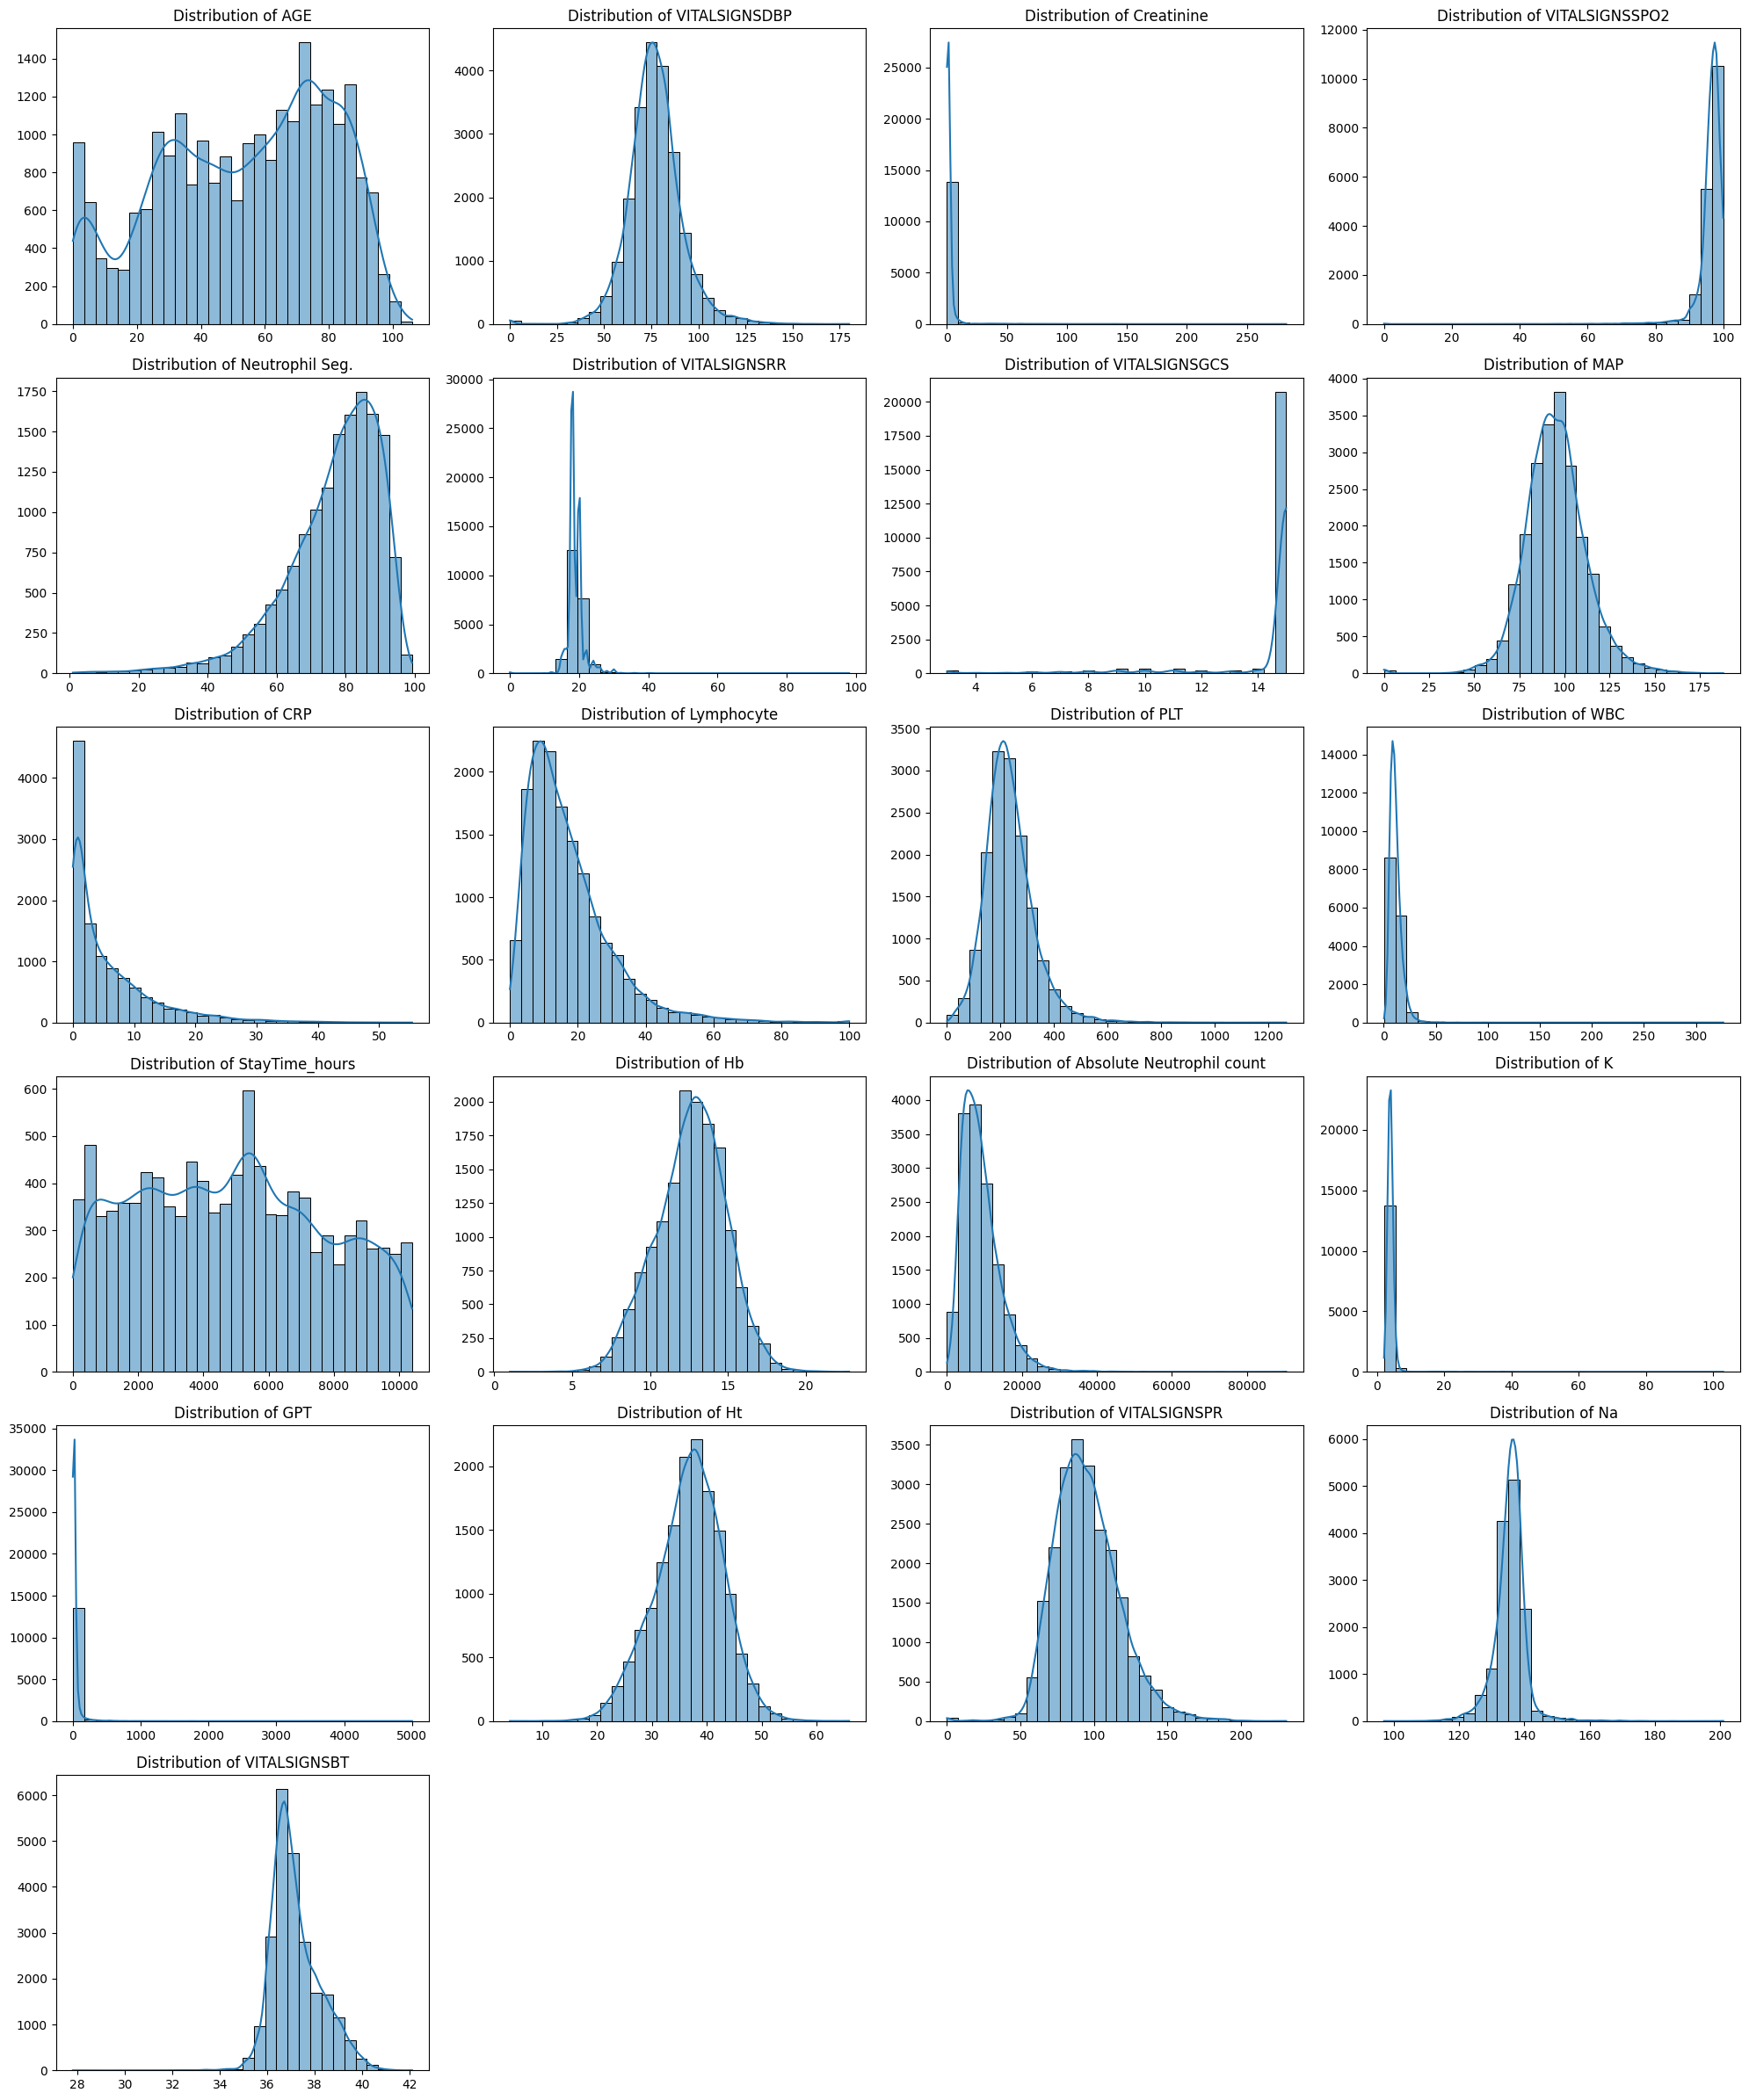

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [20]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 7395

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              205                   228   
MAP                                       216                   193   
VITALSIGNSDBP                             193                   200   
VITALSIGNSBT                              191                   199   
VITALSIGNSRR                              112                   220   
RBC                                       147                   149   
WBC                                       147                   149   
PLT                                       145                   149   
Absolute Neutrophil count                 147                   147   
Ht                                        143                   150   

                           Total_Outliers  
VITALSIGNSPR                          433  
MAP                                   409  
VITALSIGNSDBP                         393  
VITAL

In [21]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((19047, 63), (19047, 17), (4762, 63), (4762, 17))

In [23]:
X_train.isnull().sum(), X_test.isnull().sum()

(HST                      15378
 VITALSIGNSDBP             1780
 CHECKITEM29SCORE         14867
 AGE                          0
 Creatinine                7651
                          ...  
 Leukocyte level          13379
 Microscopic WBC level    13381
 VITALSIGNSPR               663
 Na                        7636
 VITALSIGNSBT               229
 Length: 63, dtype: int64,
 HST                      3869
 VITALSIGNSDBP             465
 CHECKITEM29SCORE         3690
 AGE                         0
 Creatinine               1874
                          ... 
 Leukocyte level          3292
 Microscopic WBC level    3292
 VITALSIGNSPR              182
 Na                       1884
 VITALSIGNSBT               64
 Length: 63, dtype: int64)

In [24]:
X_train.dtypes, X_test.dtypes

(HST                      float64
 VITALSIGNSDBP            float64
 CHECKITEM29SCORE         float64
 AGE                      float64
 Creatinine               float64
                           ...   
 Leukocyte level          float64
 Microscopic WBC level    float64
 VITALSIGNSPR             float64
 Na                       float64
 VITALSIGNSBT             float64
 Length: 63, dtype: object,
 HST                      float64
 VITALSIGNSDBP            float64
 CHECKITEM29SCORE         float64
 AGE                      float64
 Creatinine               float64
                           ...   
 Leukocyte level          float64
 Microscopic WBC level    float64
 VITALSIGNSPR             float64
 Na                       float64
 VITALSIGNSBT             float64
 Length: 63, dtype: object)

In [25]:
y_train.sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    4391.0
Flomoxef                       4182.0
Cefazolin                      1874.0
Cefixime                       1738.0
Ciprofloxacin                  1659.0
Azithromycin                   1626.0
Cefuroxime                     1350.0
Piperacillin/Tazobactam        1237.0
Cefoperazone/sulbactam         1127.0
Metronidazole                   835.0
Cefadroxil                      731.0
Levofloxacin                    566.0
Clindamycin                     503.0
Ceftriaxone                     494.0
Gentamicin                      490.0
Cephalexin                      422.0
Ampicillin                      324.0
dtype: float64

In [26]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
            'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [27]:
# vital sign impute

vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
              'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
              'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [28]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['RBC'] = np.log1p(X_train['RBC'])
X_test['RBC'] = np.log1p(X_test['RBC'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

X_train['HST'] = np.log1p(X_train['HST'])
X_test['HST'] = np.log1p(X_test['HST'])

X_train['CHECKITEM27'] = np.log1p(X_train['CHECKITEM27'])
X_test['CHECKITEM27'] = np.log1p(X_test['CHECKITEM27'])

X_train['O2 SAT'] = np.log1p(X_train['O2 SAT'])
X_test['O2 SAT'] = np.log1p(X_test['O2 SAT'])

X_train['APTT'] = np.log1p(X_train['APTT'])
X_test['APTT'] = np.log1p(X_test['APTT'])

X_train['PH'] = np.log1p(X_train['PH'])
X_test['PH'] = np.log1p(X_test['PH'])

X_train['CHECKITEM28A'] = np.log1p(X_train['CHECKITEM28A'])
X_test['CHECKITEM28A'] = np.log1p(X_test['CHECKITEM28A'])

In [29]:
# fill score
# score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
#               'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
#               'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
#               'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
#               'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

score_cols = ['Leukocyte level', 'Nitrite level', 'Microscopic RBC level', 'Microscopic WBC level', 'PH',
              'CHECKITEM29SCORE', 'CHECKITEM30SCORE', # 70~80% missing
              'HST','T.Bilirubin', 'PT', 'HST', 'INR', 'APTT', 'PCO2', 'HCO3', 'BE(ecf)',
              'O2 SAT', 'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 
              'CHECKITEM31SCORE', 'CHECKITEM32SCORE'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [30]:
y_train.sum(axis=1).mean() # 每人平均用1.4個抗生素

1.236362681787158

In [31]:
# drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
#              'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
#              'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
#              'CHECKITEM31SCORE', 'CHECKITEM32SCORE', 'OTHERINFECTIONSITE_flag']

drop_cols = ['OTHERINFECTIONSITE_flag']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [32]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
               'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
               'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [33]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(19047, 62)

In [34]:
y_train.columns

Index(['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin',
       'Cefadroxil', 'Cefazolin', 'Cefixime', 'Cefoperazone/sulbactam',
       'Ceftriaxone', 'Cefuroxime', 'Cephalexin', 'Ciprofloxacin',
       'Clindamycin', 'Flomoxef', 'Gentamicin', 'Levofloxacin',
       'Metronidazole', 'Piperacillin/Tazobactam'],
      dtype='object')

In [35]:
X_train.columns

Index(['HST', 'VITALSIGNSDBP', 'CHECKITEM29SCORE', 'AGE', 'Creatinine', 'PT',
       'FEVER', 'CHECKITEM27', 'VITALSIGNSSPO2', 'Neutrophil Seg.',
       'CHECKITEM28A', 'VITALSIGNSRR', 'Nitrite level', 'VITALSIGNSGCS', 'PH',
       'INFECTIONSITE4', 'O2 SAT', 'INJURELEVEL', 'AUTOIMMUNE',
       'INFECTIONSITE5', 'INFECTIONSITE3', 'CHECKITEM31SCORE',
       'CHECKITEM30SCORE', 'INFECTIONSITE2', 'MAP', 'CHECKITEM27SCORE',
       'KIDNEY', 'CRP', 'Miss_INFECTSITE_flag', 'LIVER', 'Lymphocyte',
       'CHECKITEM32SCORE', 'RBC', 'RESPIRATORY', 'CHECKITEM28SCORE',
       'Microscopic RBC level', 'T.Bilirubin', 'BE(ecf)', 'CARDIOVASCULAR',
       'INFECTIONSITE9', 'HCO3', 'DM', 'PLT', 'CANCER', 'WBC',
       'StayTime_hours', 'PCO2', 'SEX', 'Absolute Neutrophil count', 'K',
       'GPT', 'Hb', 'Ht', 'INFECTIONSITE1', 'INR', 'APTT', 'CNS',
       'Leukocyte level', 'Microscopic WBC level', 'VITALSIGNSPR', 'Na',
       'VITALSIGNSBT'],
      dtype='object')

In [36]:
# GaussianMixture?

In [37]:
cluster_features = ['WBC', 'CRP', 'Lymphocyte', 'Neutrophil Seg.',  'Absolute Neutrophil count',  'Hb', 'Lymphocyte', 'MAP', 
                    'VITALSIGNSBT', 'VITALSIGNSDBP', 'VITALSIGNSRR', 'VITALSIGNSPR', 'VITALSIGNSGCS', 'VITALSIGNSSPO2']

gmm = GaussianMixture(n_components=3, covariance_type='diag', random_state=123)

In [38]:
X_train['cluster'] = gmm.fit_predict(X_train[cluster_features])
X_test['cluster'] = gmm.predict(X_test[cluster_features])

In [39]:
gmm.aic(X_train[cluster_features]), gmm.bic(X_train[cluster_features]), gmm.score(X_train[cluster_features])

(-9570.156265736081, -8894.655085381964, 0.2557399135227616)

In [40]:
X_train['cluster'].unique()

array([0, 1, 2], dtype=int64)

In [41]:
len(X_train[X_train['cluster'] == 0]), len(X_train[X_train['cluster'] == 1]), len(X_train[X_train['cluster'] == 2])

(7642, 6660, 4745)

In [42]:
#看看每個cluster的抗生素種類和分配
X_train_cluster = X_train.copy()
df_analysis = pd.concat([X_train_cluster, y_train], axis=1)

In [43]:
for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    drug_rate = subset[y_train.columns].mean().sort_values(ascending=False)
    print(drug_rate.head(15))

cluster 0
Flomoxef                       0.312614
Amoxicillin/Clavulanic acid    0.129547
Piperacillin/Tazobactam        0.118032
Cefazolin                      0.107433
Ciprofloxacin                  0.104685
Cefoperazone/sulbactam         0.103245
Cefixime                       0.091076
Azithromycin                   0.067783
Metronidazole                  0.066867
Cefuroxime                     0.051295
Levofloxacin                   0.036770
Ceftriaxone                    0.034677
Clindamycin                    0.026695
Gentamicin                     0.025386
Ampicillin                     0.020414
dtype: float64
cluster 1
Amoxicillin/Clavulanic acid    0.369670
Flomoxef                       0.105255
Azithromycin                   0.102402
Cefixime                       0.091892
Cefuroxime                     0.090991
Cefadroxil                     0.087087
Ciprofloxacin                  0.083033
Cephalexin                     0.045195
Cefazolin                      0.033333
Clind

In [44]:
# 相對提升
global_rate = y_train.mean()

for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    cluster_rate = subset[y_train.columns].mean()
    lift = (cluster_rate / global_rate).sort_values(ascending=False) # 明顯偏?
    print(lift.head(15))

cluster 0
Piperacillin/Tazobactam        1.817425
Cefoperazone/sulbactam         1.744908
Metronidazole                  1.525295
Flomoxef                       1.423809
Ceftriaxone                    1.337022
Levofloxacin                   1.237398
Ciprofloxacin                  1.201886
Ampicillin                     1.200049
Cefazolin                      1.091926
Clindamycin                    1.010838
Cefixime                       0.998111
Gentamicin                     0.986791
Azithromycin                   0.794015
Cefuroxime                     0.723722
Amoxicillin/Clavulanic acid    0.561942
dtype: float64
cluster 1
Cefadroxil                     2.269149
Cephalexin                     2.039888
Amoxicillin/Clavulanic acid    1.603530
Cefuroxime                     1.283782
Azithromycin                   1.199544
Clindamycin                    1.080284
Cefixime                       1.007057
Ciprofloxacin                  0.953303
Levofloxacin                   0.803402
Metro

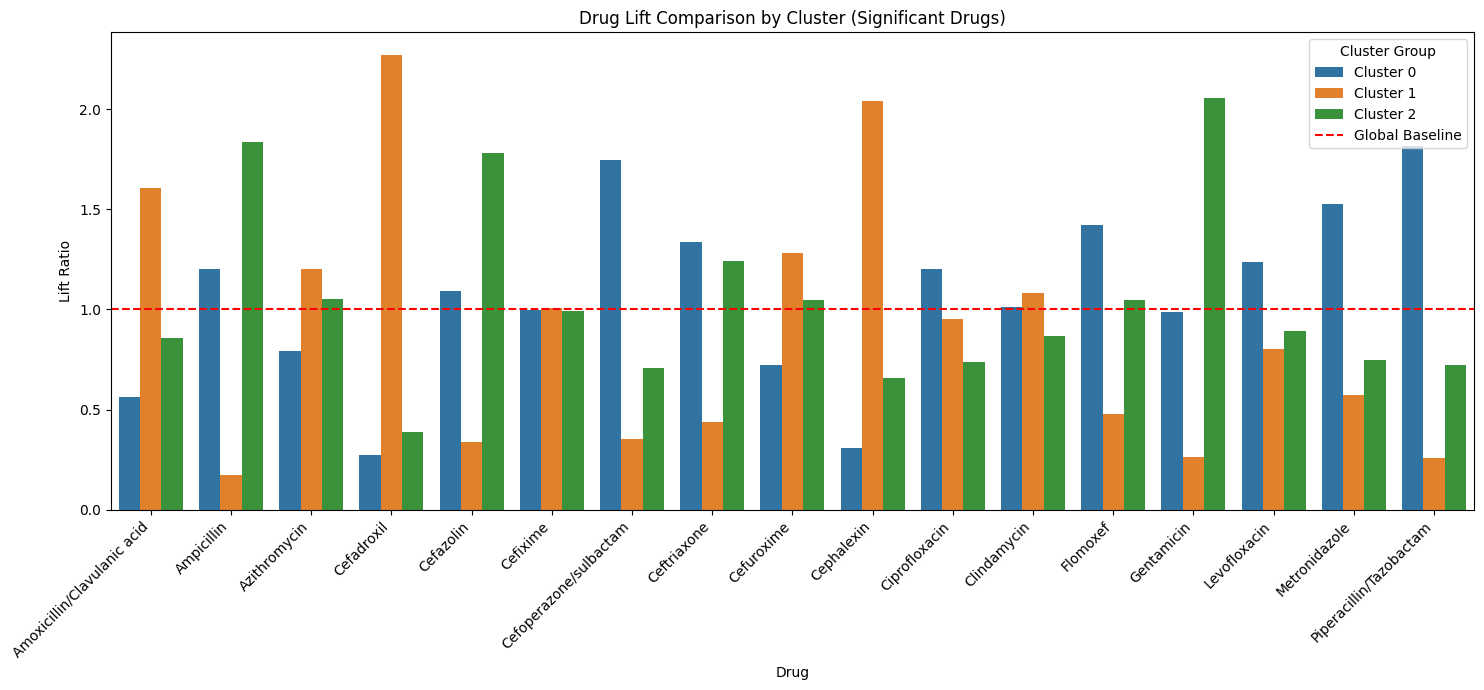

In [45]:
# 1. 整理資料存入 list
lift_records = []
global_rate = y_train.mean()

for c in sorted(df_analysis['cluster'].unique()):
    subset = df_analysis[df_analysis['cluster'] == c]
    cluster_rate = subset[y_train.columns].mean()
    lift = (cluster_rate / global_rate)
    
    for drug, val in lift.items():
        lift_records.append({
            'Cluster': f'Cluster {c}',
            'Drug': drug,
            'Lift': val
        })

df_lift_plot = pd.DataFrame(lift_records)

# 2. 繪圖：只挑出 Lift 較顯著的藥物（例如 Lift > 1.5 的藥物）
# 否則藥物太多圖會擠在一起
significant_drugs = df_lift_plot[df_lift_plot['Lift'] > 1.0]['Drug'].unique()
df_filtered = df_lift_plot[df_lift_plot['Drug'].isin(significant_drugs)]

plt.figure(figsize=(15, 7))
sns.barplot(data=df_filtered, x='Drug', y='Lift', hue='Cluster')

# 畫一條紅線代表基準線 (Lift=1)
plt.axhline(1, ls='--', color='red', label='Global Baseline')

plt.title('Drug Lift Comparison by Cluster (Significant Drugs)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Lift Ratio')
plt.legend(title='Cluster Group')
plt.tight_layout()
plt.show()


In [46]:
# 每群抗生素數量
for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    drug_num = subset[y_train.columns].sum(axis=1).mean()
    print(drug_num)

cluster 0
1.313792200994504
cluster 1
1.1453453453453453
cluster 2
1.2394099051633298


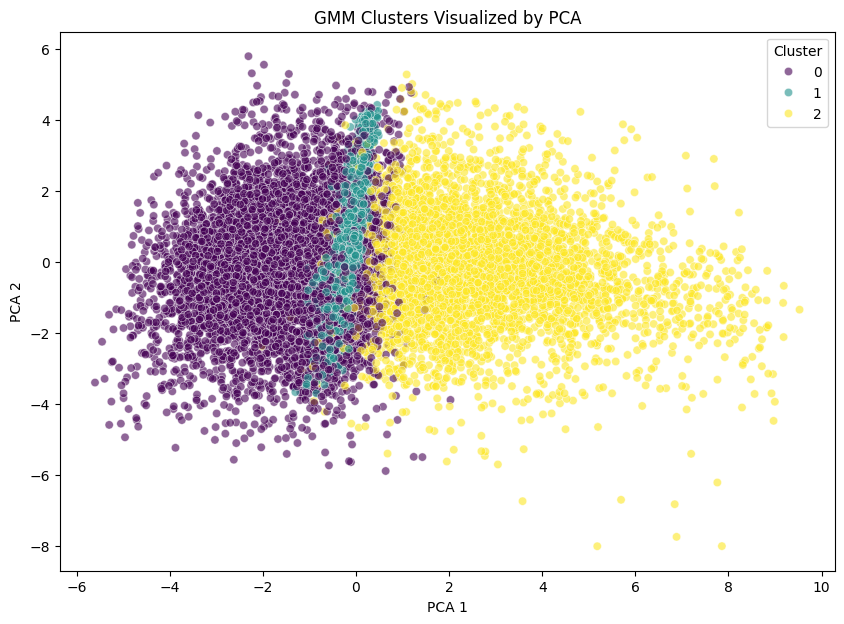

In [47]:
# PCA 降到 2 維
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train[cluster_features])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_train_pca[:, 0], 
    y=X_train_pca[:, 1], 
    hue=X_train['cluster'], # 根據 GMM 分群上色
    palette='viridis', 
    alpha=0.6
)

plt.title('GMM Clusters Visualized by PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()


In [48]:
# 挑選關鍵重症指標
severity_indicators = cluster_features

cols_to_show = [c for c in severity_indicators if c in cluster_features]

cluster_summary = X_train.groupby('cluster')[cols_to_show].mean().T
cluster_summary # 0:、1:、2:

cluster,0,1,2
WBC,0.462597,-0.001793,-0.742514
CRP,0.252666,-0.034996,-0.357808
Lymphocyte,-0.613874,-0.188458,1.253183
Neutrophil Seg.,0.614272,0.162207,-1.216979
Absolute Neutrophil count,0.589502,0.052021,-1.022432
Hb,-0.057854,0.057070,0.013074
Lymphocyte,-0.613874,-0.188458,1.253183
MAP,-0.092579,0.047006,0.083126
VITALSIGNSBT,0.256467,-0.161404,-0.186507
VITALSIGNSDBP,-0.120747,0.105810,0.045954


In [49]:
# cluster prob
cluster_prob_train = gmm.predict_proba(X_train[cluster_features])
cluster_prob_test = gmm.predict_proba(X_test[cluster_features])

In [50]:
def cluster_prob(df, cluster_prob):
    cluster_df = pd.DataFrame(
        cluster_prob,
        columns=[f'cluster_{i}' for i in range(cluster_prob.shape[1])]
    )
    final_df = pd.concat([df.reset_index(drop=True), cluster_df], axis=1)
    return final_df

X_train = cluster_prob(X_train, cluster_prob_train)
X_test = cluster_prob(X_test, cluster_prob_test)

In [51]:
X_train = X_train.drop(columns='cluster')
X_test = X_test.drop(columns='cluster')

In [52]:
X_train

,HST,VITALSIGNSDBP,CHECKITEM29SCORE,AGE,Creatinine,PT,FEVER,CHECKITEM27,VITALSIGNSSPO2,Neutrophil Seg.,CHECKITEM28A,VITALSIGNSRR,Nitrite level,VITALSIGNSGCS,PH,INFECTIONSITE4,O2 SAT,INJURELEVEL,AUTOIMMUNE,INFECTIONSITE5,INFECTIONSITE3,CHECKITEM31SCORE,CHECKITEM30SCORE,INFECTIONSITE2,MAP,CHECKITEM27SCORE,KIDNEY,CRP,Miss_INFECTSITE_flag,LIVER,Lymphocyte,CHECKITEM32SCORE,RBC,RESPIRATORY,CHECKITEM28SCORE,Microscopic RBC level,T.Bilirubin,BE(ecf),CARDIOVASCULAR,INFECTIONSITE9,HCO3,DM,PLT,CANCER,WBC,StayTime_hours,PCO2,SEX,Absolute Neutrophil count,K,GPT,Hb,Ht,INFECTIONSITE1,INR,APTT,CNS,Leukocyte level,Microscopic WBC level,VITALSIGNSPR,Na,VITALSIGNSBT,cluster_0,cluster_1,cluster_2
0,-0.048967,1.500760,-1.0,0.584529,-0.214579,-1.0,1,0.025618,-6.603174,0.162207,0.075617,3.127528,-1.0,-0.201712,0.055464,0,0.133515,1.0,0,0,0,-1.0,-1.0,0,1.477922,-1.0,0,-0.034996,0,0,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,0,0,-1.0,0,0.053874,0,-0.001793,-0.002689,-1.0,1,0.052021,-0.142570,-0.124552,0.057070,0.049251,1,-1.00,-0.075665,0,-1.0,-1.0,1.993557,0.084547,-0.590455,1.000000e+00,0.0,3.656153e-10
1,-0.048967,0.165531,-1.0,-0.881775,-0.214579,-1.0,1,0.025618,0.166246,0.162207,0.075617,0.566531,-1.0,0.304549,0.055464,0,0.133515,3.0,0,0,0,-1.0,-1.0,0,-0.281131,-1.0,0,-0.034996,1,0,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,0,0,-1.0,0,0.053874,0,-0.001793,-0.002689,-1.0,0,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,0,-1.0,-1.0,-0.102309,0.084547,-0.181667,2.676533e-25,1.0,1.117275e-26
2,-0.048967,-0.305726,-1.0,0.417681,-0.214579,-1.0,1,0.025618,0.166246,0.162207,0.075617,0.069339,-1.0,0.304549,0.055464,0,0.133515,3.0,1,0,1,-1.0,-1.0,0,-0.150831,-1.0,1,-0.034996,0,0,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,1,0,-1.0,0,0.053874,0,-0.001793,0.683361,-1.0,1,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,0,-1.0,-1.0,-0.721542,0.084547,0.222840,2.454041e-25,1.0,1.129369e-26
3,-0.048967,0.165531,-1.0,0.770135,-0.214579,-1.0,1,0.025618,0.166246,0.162207,0.075617,0.566531,-1.0,-0.707973,0.055464,0,0.133515,3.0,0,0,0,-1.0,-1.0,1,-0.281131,-1.0,0,-0.034996,0,0,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,0,0,-1.0,0,0.053874,0,-0.001793,-0.002689,-1.0,1,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,0,-1.0,-1.0,0.183491,0.084547,-0.487851,9.708914e-01,0.0,2.910862e-02
4,-0.048967,0.950960,-1.0,-0.247999,-0.214579,-1.0,1,0.025618,0.166246,0.162207,0.075617,-0.453361,-1.0,0.304549,0.055464,0,0.133515,3.0,0,0,0,-1.0,-1.0,0,0.565820,-1.0,0,-0.034996,1,0,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,0,0,-1.0,0,0.053874,0,-0.001793,0.578680,-1.0,1,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,0,-1.0,-1.0,-0.626276,0.084547,-0.385520,1.447605e-25,1.0,1.156279e-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19042,-0.048967,1.186588,-1.0,0.821622,-0.214579,-1.0,1,0.025618,-1.223814,0.162207,0.075617,-1.586796,-1.0,0.304549,0.055464,0,0.133515,3.0,1,0,0,-1.0,-1.0,0,1.347622,-1.0,1,-0.034996,1,1,-0.188458,-1.0,0.108425,1,-1.0,-1.0,-1.0,-0.015995,1,0,-1.0,0,0.053874,1,-0.001793,-0.002689,-1.0,1,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,1,-1.0,-1.0,0.135858,0.084547,-0.385520,1.099362e-24,1.0,2.842185e-26
19043,-0.048967,-0.384269,-1.0,0.630140,-0.214579,-1.0,1,0.025618,0.166246,0.162207,0.075617,-0.453361,-1.0,0.304549,0.055464,0,0.133515,3.0,0,0,1,-1.0,-1.0,0,-0.476581,-1.0,1,-0.034996,0,1,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,1,0,-1.0,1,0.053874,0,-0.001793,-0.002689,-1.0,0,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,1,-1.0,-1.0,-1.054975,0.084547,-0.796482,1.696008e-25,1.0,1.220048e-26
19044,-0.048967,-1.719498,-1.0,-0.881775,-0.442991,-1.0,1,0.025618,0.166246,-0.758419,0.075617,0.566

In [53]:
X_train.columns

Index(['HST', 'VITALSIGNSDBP', 'CHECKITEM29SCORE', 'AGE', 'Creatinine', 'PT',
       'FEVER', 'CHECKITEM27', 'VITALSIGNSSPO2', 'Neutrophil Seg.',
       'CHECKITEM28A', 'VITALSIGNSRR', 'Nitrite level', 'VITALSIGNSGCS', 'PH',
       'INFECTIONSITE4', 'O2 SAT', 'INJURELEVEL', 'AUTOIMMUNE',
       'INFECTIONSITE5', 'INFECTIONSITE3', 'CHECKITEM31SCORE',
       'CHECKITEM30SCORE', 'INFECTIONSITE2', 'MAP', 'CHECKITEM27SCORE',
       'KIDNEY', 'CRP', 'Miss_INFECTSITE_flag', 'LIVER', 'Lymphocyte',
       'CHECKITEM32SCORE', 'RBC', 'RESPIRATORY', 'CHECKITEM28SCORE',
       'Microscopic RBC level', 'T.Bilirubin', 'BE(ecf)', 'CARDIOVASCULAR',
       'INFECTIONSITE9', 'HCO3', 'DM', 'PLT', 'CANCER', 'WBC',
       'StayTime_hours', 'PCO2', 'SEX', 'Absolute Neutrophil count', 'K',
       'GPT', 'Hb', 'Ht', 'INFECTIONSITE1', 'INR', 'APTT', 'CNS',
       'Leukocyte level', 'Microscopic WBC level', 'VITALSIGNSPR', 'Na',
       'VITALSIGNSBT', 'cluster_0', 'cluster_1', 'cluster_2'],
      dtype='object')

In [54]:
base_model = XGBClassifier(n_estimators=300,
                           max_depth=5,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           eval_metric='logloss',
                           gamma=0,
                           reg_alpha=2,
                           reg_lambda=0.0,
                           min_child_weight=1,
                           scale_pos_weight=3,
                           random_state =123,
                           n_jobs=-1
    )

multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, y_train) # sample_weight=sample_weight

,estimator,"XGBClassifier...ree=None, ...)"
,n_jobs,None
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [55]:
X_train

,HST,VITALSIGNSDBP,CHECKITEM29SCORE,AGE,Creatinine,PT,FEVER,CHECKITEM27,VITALSIGNSSPO2,Neutrophil Seg.,CHECKITEM28A,VITALSIGNSRR,Nitrite level,VITALSIGNSGCS,PH,INFECTIONSITE4,O2 SAT,INJURELEVEL,AUTOIMMUNE,INFECTIONSITE5,INFECTIONSITE3,CHECKITEM31SCORE,CHECKITEM30SCORE,INFECTIONSITE2,MAP,CHECKITEM27SCORE,KIDNEY,CRP,Miss_INFECTSITE_flag,LIVER,Lymphocyte,CHECKITEM32SCORE,RBC,RESPIRATORY,CHECKITEM28SCORE,Microscopic RBC level,T.Bilirubin,BE(ecf),CARDIOVASCULAR,INFECTIONSITE9,HCO3,DM,PLT,CANCER,WBC,StayTime_hours,PCO2,SEX,Absolute Neutrophil count,K,GPT,Hb,Ht,INFECTIONSITE1,INR,APTT,CNS,Leukocyte level,Microscopic WBC level,VITALSIGNSPR,Na,VITALSIGNSBT,cluster_0,cluster_1,cluster_2
0,-0.048967,1.500760,-1.0,0.584529,-0.214579,-1.0,1,0.025618,-6.603174,0.162207,0.075617,3.127528,-1.0,-0.201712,0.055464,0,0.133515,1.0,0,0,0,-1.0,-1.0,0,1.477922,-1.0,0,-0.034996,0,0,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,0,0,-1.0,0,0.053874,0,-0.001793,-0.002689,-1.0,1,0.052021,-0.142570,-0.124552,0.057070,0.049251,1,-1.00,-0.075665,0,-1.0,-1.0,1.993557,0.084547,-0.590455,1.000000e+00,0.0,3.656153e-10
1,-0.048967,0.165531,-1.0,-0.881775,-0.214579,-1.0,1,0.025618,0.166246,0.162207,0.075617,0.566531,-1.0,0.304549,0.055464,0,0.133515,3.0,0,0,0,-1.0,-1.0,0,-0.281131,-1.0,0,-0.034996,1,0,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,0,0,-1.0,0,0.053874,0,-0.001793,-0.002689,-1.0,0,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,0,-1.0,-1.0,-0.102309,0.084547,-0.181667,2.676533e-25,1.0,1.117275e-26
2,-0.048967,-0.305726,-1.0,0.417681,-0.214579,-1.0,1,0.025618,0.166246,0.162207,0.075617,0.069339,-1.0,0.304549,0.055464,0,0.133515,3.0,1,0,1,-1.0,-1.0,0,-0.150831,-1.0,1,-0.034996,0,0,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,1,0,-1.0,0,0.053874,0,-0.001793,0.683361,-1.0,1,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,0,-1.0,-1.0,-0.721542,0.084547,0.222840,2.454041e-25,1.0,1.129369e-26
3,-0.048967,0.165531,-1.0,0.770135,-0.214579,-1.0,1,0.025618,0.166246,0.162207,0.075617,0.566531,-1.0,-0.707973,0.055464,0,0.133515,3.0,0,0,0,-1.0,-1.0,1,-0.281131,-1.0,0,-0.034996,0,0,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,0,0,-1.0,0,0.053874,0,-0.001793,-0.002689,-1.0,1,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,0,-1.0,-1.0,0.183491,0.084547,-0.487851,9.708914e-01,0.0,2.910862e-02
4,-0.048967,0.950960,-1.0,-0.247999,-0.214579,-1.0,1,0.025618,0.166246,0.162207,0.075617,-0.453361,-1.0,0.304549,0.055464,0,0.133515,3.0,0,0,0,-1.0,-1.0,0,0.565820,-1.0,0,-0.034996,1,0,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,0,0,-1.0,0,0.053874,0,-0.001793,0.578680,-1.0,1,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,0,-1.0,-1.0,-0.626276,0.084547,-0.385520,1.447605e-25,1.0,1.156279e-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19042,-0.048967,1.186588,-1.0,0.821622,-0.214579,-1.0,1,0.025618,-1.223814,0.162207,0.075617,-1.586796,-1.0,0.304549,0.055464,0,0.133515,3.0,1,0,0,-1.0,-1.0,0,1.347622,-1.0,1,-0.034996,1,1,-0.188458,-1.0,0.108425,1,-1.0,-1.0,-1.0,-0.015995,1,0,-1.0,0,0.053874,1,-0.001793,-0.002689,-1.0,1,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,1,-1.0,-1.0,0.135858,0.084547,-0.385520,1.099362e-24,1.0,2.842185e-26
19043,-0.048967,-0.384269,-1.0,0.630140,-0.214579,-1.0,1,0.025618,0.166246,0.162207,0.075617,-0.453361,-1.0,0.304549,0.055464,0,0.133515,3.0,0,0,1,-1.0,-1.0,0,-0.476581,-1.0,1,-0.034996,0,1,-0.188458,-1.0,0.108425,0,-1.0,-1.0,-1.0,-0.015995,1,0,-1.0,1,0.053874,0,-0.001793,-0.002689,-1.0,0,0.052021,-0.142570,-0.124552,0.057070,0.049251,0,-1.00,-0.075665,1,-1.0,-1.0,-1.054975,0.084547,-0.796482,1.696008e-25,1.0,1.220048e-26
19044,-0.048967,-1.719498,-1.0,-0.881775,-0.442991,-1.0,1,0.025618,0.166246,-0.758419,0.075617,0.566

In [56]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.7218410008552618
0.7354947356735881


In [57]:
# # # 原始機率
y_prob_list = np.column_stack([multi_model.predict_proba(X_test)[:, 1] for multi_model in multi_model.estimators_])
y_pred = multi_model.predict(X_test)
# print(y_pred[:5])

# 計算每種抗生素的使用頻率
drug_freq = y_train.mean(axis=0).values
drug_freq = np.clip(drug_freq, 1e-6, None) #避免除以0

# 計算每種抗生素權重(F1/recall)
drug_weight = []

# 用y_train去計算f1，或用cv
for i, col in enumerate(y_train.columns):
    # score = 1 / (f1_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
    score = 1 / (recall_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
    drug_weight.append(score)

drug_weight = np.clip(drug_weight, 1e-6, None)

#  normalize
drug_weight = drug_weight / drug_weight.mean()

alpha = 0.05 # penalty
belta = 0.5

# adjusted_scores = y_prob_list / (drug_freq ** alpha)
# adjusted_scores = np.log(y_prob_list + 1e-6) - np.log(drug_freq ** alpha)
adjusted_scores = (np.log(y_prob_list + 1e-6)+ belta * np.log(drug_weight)- alpha * np.log(drug_freq))
# adjusted_scores = y_prob_list * drug_weight ** belta - alpha * np.log(drug_freq)


In [58]:
# # adjusted_scores Softmax
exp_scores = np.exp(adjusted_scores)
scores_softmax = exp_scores / exp_scores.sum(axis=1, keepdims=True)

In [59]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.5123144254698361
0.3609563809777536


In [60]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

0.44685006299873997

In [61]:
hamming_loss(y_test, y_pred)

0.07020036069866838

In [62]:
target_names = y_train.columns

for i, col in enumerate(target_names):
    print(f'-- {col} --')
    print(classification_report(y_train.iloc[:, i], y_pred_train[:, i]))

-- Amoxicillin/Clavulanic acid --
              precision    recall  f1-score   support

         0.0       0.97      0.77      0.86     14656
         1.0       0.55      0.93      0.69      4391

    accuracy                           0.81     19047
   macro avg       0.76      0.85      0.77     19047
weighted avg       0.87      0.81      0.82     19047

-- Ampicillin --
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     18723
         1.0       0.99      0.99      0.99       324

    accuracy                           1.00     19047
   macro avg       1.00      1.00      1.00     19047
weighted avg       1.00      1.00      1.00     19047

-- Azithromycin --
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97     17421
         1.0       0.64      0.68      0.66      1626

    accuracy                           0.94     19047
   macro avg       0.81      0.82      0.81     19047
weig

In [63]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, scores, k=3):

    topk = np.argsort(scores, axis=1)[:, ::-1][:, :k]  # 排序

    APs = []

    for i in range(len(y_true)):
        actual = np.where(y_true[i] == 1)[0]

        if len(actual) == 0:
            continue

        hits = 0
        score = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)

        APs.append(score / min(len(actual), k))

    return np.mean(APs)


################################

k=5
hitk = hit_rate_at_k(y_test.values, adjusted_scores, k=k)
print(f"Hit@{k}: {hitk}")
precisionk = precision_at_k(y_test.values, adjusted_scores, k=k)
print(f"precision@{k}: {precisionk}")
recall_k = recall_at_k(y_test.values, adjusted_scores, k=k)
print(f"Recall@{k}: {recall_k}")
map_k = map_at_k(y_test.values, adjusted_scores, k=k)
print(f"MAP@{k}: {map_k}")

Hit@5: 0.9128517429651407
precision@5: 0.21516169676607635
Recall@5: 0.8819543609127818
MAP@5: 0.6419848686359606


In [64]:
hit1 = hit_rate_at_k(y_test.values, adjusted_scores, k=1)
hit1

0.5247795044099118

In [65]:
drug_names = y_train.columns


def show_top3_prediction(patient_idx, proba_matrix, y_true, drug_names, k=3):
    #預測
    probs = proba_matrix[patient_idx]
    topk_idx = np.argsort(probs)[-k:][::-1]

    #實際
    actual_idx = np.where(y_true[patient_idx] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs if actual_drugs else '無'}")
    print("\n推薦藥物:")
    for rank, idx in enumerate(topk_idx, 1):
        print(f"{rank}. {drug_names[idx]} (Score: {probs[idx]:.4f})")
    print("="*50)

for i in range(10):
    show_top3_prediction(i, scores_softmax, y_test.values, drug_names, k=5)

實際給藥: ['Cefadroxil']

推薦藥物:
1. Amoxicillin/Clavulanic acid (Score: 0.2595)
2. Cefadroxil (Score: 0.1708)
3. Ciprofloxacin (Score: 0.1544)
4. Cefixime (Score: 0.1338)
5. Cefuroxime (Score: 0.1244)
實際給藥: ['Cefixime', 'Ceftriaxone', 'Metronidazole']

推薦藥物:
1. Flomoxef (Score: 0.2951)
2. Cefixime (Score: 0.2725)
3. Ciprofloxacin (Score: 0.2096)
4. Cefuroxime (Score: 0.0720)
5. Cefoperazone/sulbactam (Score: 0.0500)
實際給藥: ['Cefazolin', 'Clindamycin']

推薦藥物:
1. Cefazolin (Score: 0.5645)
2. Gentamicin (Score: 0.2296)
3. Amoxicillin/Clavulanic acid (Score: 0.0622)
4. Cefuroxime (Score: 0.0362)
5. Ciprofloxacin (Score: 0.0321)
實際給藥: ['Flomoxef']

推薦藥物:
1. Flomoxef (Score: 0.4506)
2. Piperacillin/Tazobactam (Score: 0.1230)
3. Levofloxacin (Score: 0.1038)
4. Ceftriaxone (Score: 0.0977)
5. Cefoperazone/sulbactam (Score: 0.0769)
實際給藥: ['Cefuroxime']

推薦藥物:
1. Amoxicillin/Clavulanic acid (Score: 0.3451)
2. Azithromycin (Score: 0.3013)
3. Cefixime (Score: 0.0857)
4. Ciprofloxacin (Score: 0.0650)
5. C

In [66]:
def explain_topk_patient(i, X, y_true, multi_model, scores, drug_names, k=3):
    x = X.iloc[i:i+1]
    probs = scores[i]

    topk_idx = np.argsort(probs)[-k:][::-1]

    actual_idx = np.where(y_true.iloc[i] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs}")
    print("="*60)
    cluster_columns = ['cluster_0', 'cluster_1', 'cluster_2']
    cluster_prob = X.iloc[i][cluster_columns].values
    cluster_label = np.argmax(cluster_prob)
    cluster_map = {0:'表現較嚴重', 1:'表現中等', 2:'表現較輕微'}
    print(f"病人嚴重傾向: {cluster_map[cluster_label]}")
    # print("\n以下Score 為綜合模型信心與以往開藥的頻率的計分，越高表示依照以往經驗，可能更合適。")
    # print("以下Shap 為每個特徵對該抗生素推薦的貢獻比例，例如:+10% 為增加10%的推薦力道。")
    

    for rank, idx in enumerate(topk_idx, 1):
        model = multi_model.estimators_[idx]
        # 0.令
        booster = model.get_booster()
        
        # 1. 將 pandas 的 x 轉換為 XGBoost 專用的 DMatrix
        dtrain = xgb.DMatrix(x)

        # 2. 執行預測取得 SHAP 值 (pred_contribs=True)
        # 這會回傳一個 numpy array，形狀為 (1, 特徵數 + 1)
        shap_matrix = booster.predict(dtrain, pred_contribs=True)

        # 3. 拿掉最後一欄 (Bias/Intercept)，只留特徵貢獻度
        shap_values = shap_matrix[:, :-1]

        # 4. 整理成 Series (注意：這裡不需要再呼叫 explainer.shap_values 了)
        all_contrib = pd.Series(shap_values[0],index=X.columns)

        # 5. 篩選絕對值大於 0.1 的特徵 (即 > 0.1 或 < -0.1)
        contrib = all_contrib[all_contrib.abs() > 0.1].sort_values(key=abs, ascending=False)
        
        # 6.移除群聚特徵
        contrib = contrib.drop(labels=['cluster_0', 'cluster_1', 'cluster_2',
                                       'Miss_INFECTSITE_flag', 'StayTime_hours'], 
                               errors='ignore')

        
        # 7. 如果篩選後特徵太多，最多只顯示前 10 個
        contrib = contrib.head(10)
        
        print(f"\n{rank}: {drug_names[idx]}")
        print(f"\nScore: {probs[idx]:.4f}")
        print("\n主要影響特徵 and Shap值:")
        total_impact = contrib.abs().sum()
        for feat, val in contrib.items():
            pct = (val / total_impact) * 100
            direction = "+" if val > 0 else "-" 
            print(f"{feat:<15}: {direction} {abs(pct):.1f}%")
            
        # print(contrib)
        print("-"*40)

In [67]:
# explain_topk_patient(0, X_test, y_test, multi_model, scores_softmax, y_test.columns, k=5)

In [68]:
for i in range(5):
    explain = explain_topk_patient(i, X_test, y_test, multi_model, scores_softmax, y_test.columns, k=5)

實際給藥: ['Cefadroxil']
病人嚴重傾向: 表現較嚴重

以下Score 為綜合模型信心與以往開藥的頻率的計分，越高表示依照以往經驗，可能更合適。
以下Shap 為每個特徵對該抗生素推薦的貢獻比例，例如:+10% 為增加10%的推薦力道。

1: Amoxicillin/Clavulanic acid

Score: 0.2595

主要影響特徵 and Shap值:
INFECTIONSITE2 : + 21.7%
CRP            : + 20.0%
PT             : + 13.6%
Nitrite level  : + 12.8%
INFECTIONSITE5 : - 12.7%
SEX            : - 10.2%
VITALSIGNSPR   : - 9.1%
----------------------------------------

2: Cefadroxil

Score: 0.1708

主要影響特徵 and Shap值:
VITALSIGNSPR   : + 33.0%
Ht             : + 18.1%
CNS            : + 18.0%
MAP            : + 16.8%
LIVER          : - 14.1%
----------------------------------------

3: Ciprofloxacin

Score: 0.1544

主要影響特徵 and Shap值:
AGE            : + 24.6%
INFECTIONSITE1 : + 19.3%
VITALSIGNSPR   : + 18.0%
INJURELEVEL    : + 13.8%
T.Bilirubin    : - 12.3%
PT             : + 11.9%
----------------------------------------

4: Cefixime

Score: 0.1338

主要影響特徵 and Shap值:
PT             : + 50.1%
T.Bilirubin    : - 49.9%
-------------------------------------